### ClarityXR — Explainable Pneumonia Detection with Uncertainty Quantification

### An AI-powered chest X-ray classifier that detects pneumonia using  DenseNet-121, quantifies prediction uncertainty through Monte Carlo Dropout, and provides visual explanations via Grad-CAM. Built on the RSNA Pneumonia Detection dataset (30,227 chest X-rays).

### **Tools:** Python, PyTorch, torchvision, pydicom, scikit-learn, matplotlib
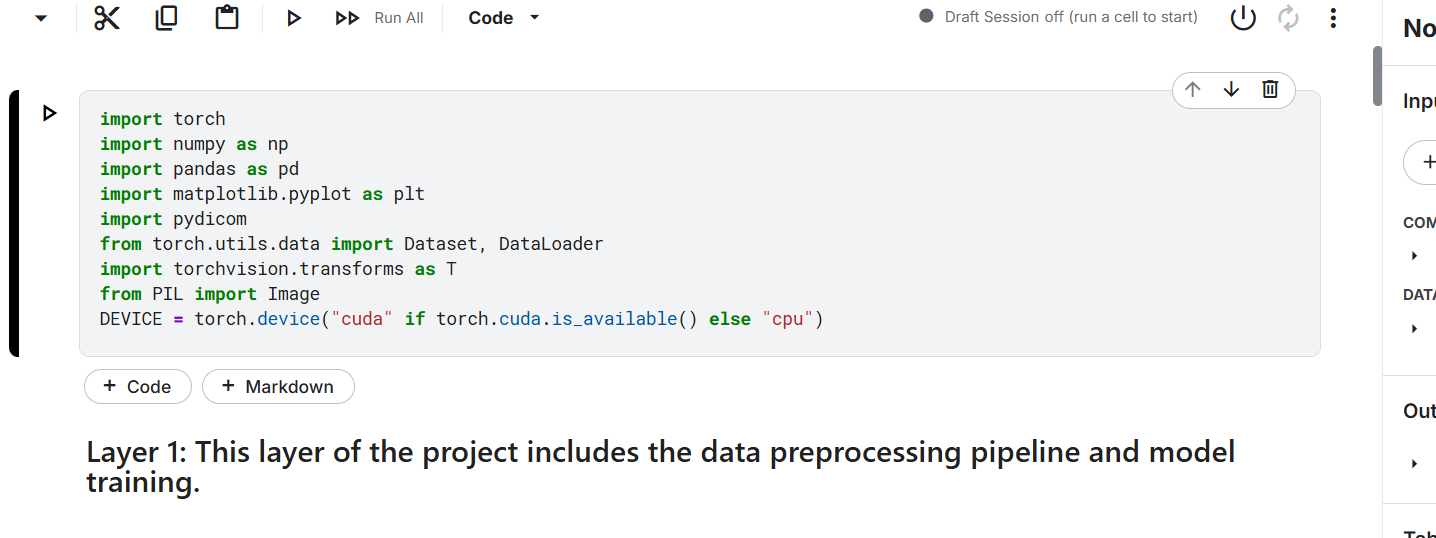

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Layer 1: This layer of the project includes the data preprocessing pipeline and model training.

In [4]:
class RSNADataset(Dataset):
    """
    Custom PyTorch Dataset for loading RSNA pneumonia chest X-Rays.

    Handles DICOM file loading, grayscale to RGB conversion, pixel normalization.
    Supports lazy-loading so images are read from disk one at a time rather than loaded to memory all at once
    
    Args
    df: Dataframe with 'PatientID'and 'Target' columns
    img_dir: Path directory containing .dcm files.
    transform: torchvision transform pipeline to apply.
    """
    def __init__(self, df, img_dir, transform) :
        self.df = df
        self.image_dir = img_dir
        self.transform = transform
    def __len__(self) :
        return len(self.df)
    def __getitem__(self, index) :
        """
        Load and preprocess a single X-Ray image item and its label by index.
        """
        row = self.df.iloc[index]
        label = row["Target"]
        label = torch.tensor(label, dtype = torch.float32)
        img_path = self.image_dir + "/" + row["patientId"] + ".dcm"
        dicom = pydicom.dcmread(img_path)
        image = dicom.pixel_array
        image = (image - image.min()) / (image.max() - image.min()) * 255
        image = image.astype(np.uint8)
        image = Image.fromarray(image)
        image = image.convert("RGB")
        image = self.transform(image)
        return image, label

## This cell applies data augmentation and necessary transformations to the X-Ray images based on training and validation sets.

In [5]:
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(0.50),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
df = pd.read_csv("/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv")
print(df.shape)
df.head()

(30227, 6)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


## Since there are less positive cases then negative cases in the dataset, a weighted sampler is used to achieve better generalization and performance.


In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler

# Split by unique patients to prevent data leakage
patient_ids = df["patientId"].unique()
train_ids, val_ids = train_test_split(patient_ids, test_size=0.2, random_state=42)

train_df = df[df["patientId"].isin(train_ids)]
val_df   = df[df["patientId"].isin(val_ids)]

class_counts = train_df["Target"].value_counts()
print(class_counts)
class_weights = 1 / class_counts
sample_weights = train_df["Target"].map(class_weights)

sample_weights = torch.tensor(sample_weights.values, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dataset = RSNADataset(train_df, "/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images", transform = train_transform)
val_dataset = RSNADataset(val_df, "/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images", transform = val_transform)

train_loader = DataLoader(train_dataset, batch_size = 64, sampler = sampler, num_workers = 2, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = False, num_workers = 2, pin_memory = True)


Target
0    16564
1     7604
Name: count, dtype: int64


### Data Visualization: The two cells below visualize the X-Ray images taken from the dataset as well as the class distribution of the images based on their labels.

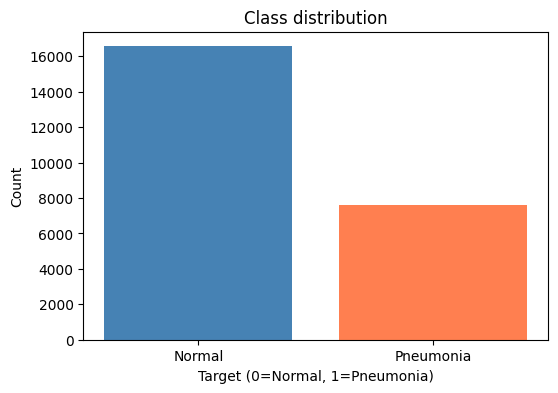

In [8]:
plt.figure(figsize = (6, 4))
plt.bar(class_counts.index, class_counts.values, color = ["steelblue", "coral"])
plt.title("Class distribution")
plt.xlabel("Target (0=Normal, 1=Pneumonia)")
plt.ylabel("Count")
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.show()

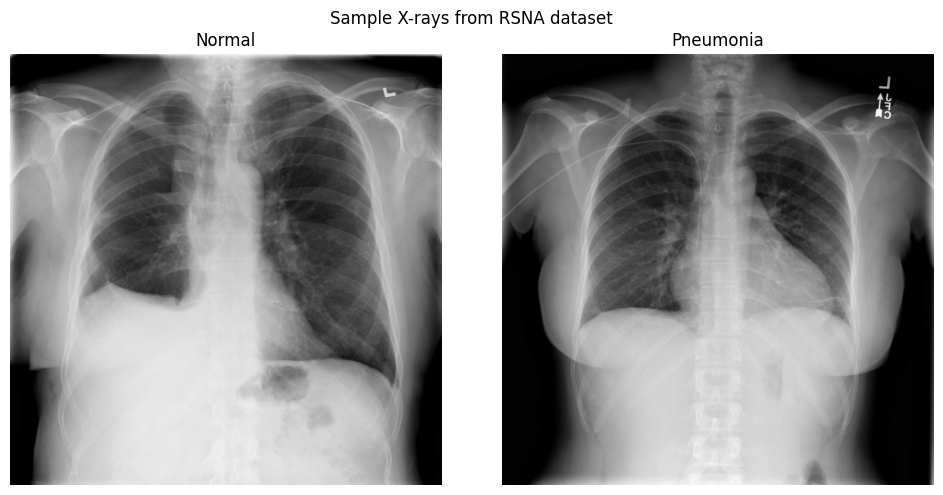

In [9]:
normal_row = val_df[val_df["Target"] == 0].iloc[0]
pneumonia_row = val_df[val_df["Target"] == 1].iloc[0]

IMG_DIR = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images"

normal_dicom = pydicom.dcmread(IMG_DIR + "/" + normal_row["patientId"] + ".dcm")
normal_img = normal_dicom.pixel_array

pneumonia_dicom = pydicom.dcmread(IMG_DIR + "/" + pneumonia_row["patientId"] + ".dcm")
pneumonia_img = pneumonia_dicom.pixel_array

pneumonia_img = (pneumonia_img - pneumonia_img.min()) / (pneumonia_img.max() - pneumonia_img.min()) * 255

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(normal_img, cmap="gray")
axes[0].set_title("Normal")
axes[0].axis("off")

axes[1].imshow(pneumonia_img, cmap="gray")
axes[1].set_title("Pneumonia")
axes[1].axis("off")

plt.suptitle("Sample X-rays from RSNA dataset")
plt.tight_layout()
plt.show()

### Model Architecture: DenseNet121 was selected for fine-tuning in this project for a variety of factors.
### 1.Clinical Predecent: DenseNet121 has been previously used by a variety of research papers in clinical scenarios.Rajpurkar et al. (2017) used DenseNet-121 in  CheXNet to achieve radiologist-level pneumonia detection on chest X-rays (arXiv:1711.05225).This architecture is a baseline model for chest X-Ray classification in medical AI research
### 2.Dense Connectivity: Unlike traditional CNN's where each layer connects only to the next, DenseNet connects every layer with each other.This creates paths between early and later layers encouraging feature reuse and better gradient flow 
### 3. Transfer-Learning Efficiency: DenseNet121 pretrained on ImageNet provides strong lower level feature extraction.By freezing early layers and fine-tuning only denseblock4 and a custom classifier head we achieve strong performance with significantly less training

### Modifications to the Architecture:
### - The classifier head is replaced with (nn.Dropout(p = 0.5), nn.Linear(in_features = 1024, out_features = 1)). Dropout enables Monte Carlo uncertainty estimation at inference time.
### - denseblock4 unfrozen for fine tuning with a lower learning rate (1e-5) while the classifier is trained at (1e-4)

### Final Final model achieved an AUC of 0.8836 on the validation set after 10 epochs of training.


In [10]:
import torchvision.models as models
import torch.nn as nn
model = models.densenet121(weights = models.DenseNet121_Weights.IMAGENET1K_V1)
print(model.classifier)
model.classifier = nn.Sequential(nn.Dropout(p = 0.5), nn.Linear(in_features = 1024, out_features = 1))
for param in model.parameters() :
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

for param in model.features.denseblock4.parameters():
    param.requires_grad = True
    

model = model.to(DEVICE)

pos_weight = torch.tensor([class_counts[0] / class_counts[1]], dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam([
    {"params": model.features.denseblock4.parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 196MB/s]


Linear(in_features=1024, out_features=1000, bias=True)


## In the training pipeline the weights are saved into a dataset to avoid persistence issues and increase training efficiency.

In [11]:
import json, os, shutil
from sklearn.metrics import roc_auc_score

# Prepare upload folder once
os.makedirs("/kaggle/working/model-upload", exist_ok=True)
metadata = {
    "title": "rsna-model-weights",
    "id": "aytunsarandal/rsna-model-weights",
    "licenses": [{"name": "CC0-1.0"}]
}
with open("/kaggle/working/model-upload/dataset-metadata.json", "w") as f:
    json.dump(metadata, f)

NUM_EPOCHS = 10
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0
    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            all_preds.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    auc = roc_auc_score(all_labels, all_preds)

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | AUC: {auc:.4f}")

    # Save locally
    torch.save(model.state_dict(), f"model_epoch{epoch+1}.pth")

    # Upload to dataset after every epoch (overwrites previous)
    shutil.copy(f"model_epoch{epoch+1}.pth", "/kaggle/working/model-upload/best_model.pth")
    os.system("kaggle datasets version -p /kaggle/working/model-upload -m 'epoch {}'".format(epoch+1))
    print(f"  → Uploaded to dataset (epoch {epoch+1})")

KeyboardInterrupt: 

In [12]:
model.load_state_dict(torch.load(
    "/kaggle/input/datasets/aytunsarandal/rsna-model-weights/best_model.pth",
    map_location=DEVICE
))

<All keys matched successfully>

## Layer 2: Standard classification output has no certainty or sufficient explainability because it is a single deterministic prediction made by the model.In a clinical setting, this is insufficient as clinicians need to know in what cases to trust the model and when to focus on manual review.

### Monte Carlo Dropout(MC-Dropout) addresses this by keeping dropout active during inference and making multiple forward passes for each image.Each pass produces a slightly varying prediction due to random deactivation of neurons.The mean of these predictions serve as the final diagnosis.The standard deviation is used as a estimation of uncertainty where high variance indicates the model is uncertain serving as a direct measure of confidence.

### This approach is grounded in the theoretical framework established by  Gal & Ghahramani (2016), which proved that dropout at inference time  is mathematically equivalent to approximate Bayesian inference (arXiv:1506.02142)


In [13]:
def enable_dropout(model):
    """
    Selectively reactivate dropout layers during inference.

    After model.eval() disables all dropout and freezes BatchNorm, 
    this function re-enables only dropout layers while keeping
    BatchNorm frozen - required for MC Dropout inference.
    """
    for module in model.modules():
        if (isinstance(module, nn.Dropout)):
            module.train()

In [14]:
model.eval()
enable_dropout(model)

for name, module in model.named_modules() :
    if isinstance(module, nn.Dropout) :
        print(f"{name} — training mode: {module.training}")

classifier.0 — training mode: True


In [15]:
def mc_dropout_predict(model, image, n_iterations=30):
    """
    Run Monte Carlo Dropout on a single image.

    Performs N Stochastic forward passes while keeping dropout active and BatchNorm frozen 
    returning the mean prediction and standard deviation as a measure of model uncertainty.
    Based on Gal & Gahramani (2016), arXiv:1506.02142.
    
    Args:
        model: Trained DenseNet-121 with dropout in classifier
        image: Preprocessed image tensor of shape [1, 3, 224, 224]
        n_iterations: Number of stochastic forward passes (default: 30)
    
    Returns:
        mean_pred: Average predicted probability of pneumonia
        std_pred: Standard deviation across N passes (uncertainty)
    """
    model.eval()
    enable_dropout(model)

    predictions = []
    with torch.no_grad() :
        for i in range(n_iterations):
            output = model(image.to(DEVICE)).squeeze(1)
            prob = torch.sigmoid(output).cpu().numpy()
            predictions.append(prob)
            
    predictions = np.array(predictions)
    mean_pred = predictions.mean()
    std_pred = predictions.std()
    return mean_pred, std_pred




In [16]:
results = []
for i in range(100):
    test_image, test_label = val_dataset[i]
    test_image = test_image.unsqueeze(0)
    mean_pred, std_pred = mc_dropout_predict(model, test_image, n_iterations=30)
    
    predicted = 1 if mean_pred > 0.5 else 0
    correct = predicted == int(test_label)
    
    results.append({
        "mean_pred": float(mean_pred),
        "std_pred": float(std_pred),
        "correct": correct
    })

results_df = pd.DataFrame(results)

The reverse Parabola shape of the graph indicates that the model is really sure among the edges.The cases where the model is certain that it is a negative and positive have lower uncertainty values.However if the models mean prediction is 0.5 which is right in the middle it indicates that is not sure so the value of std is larger.

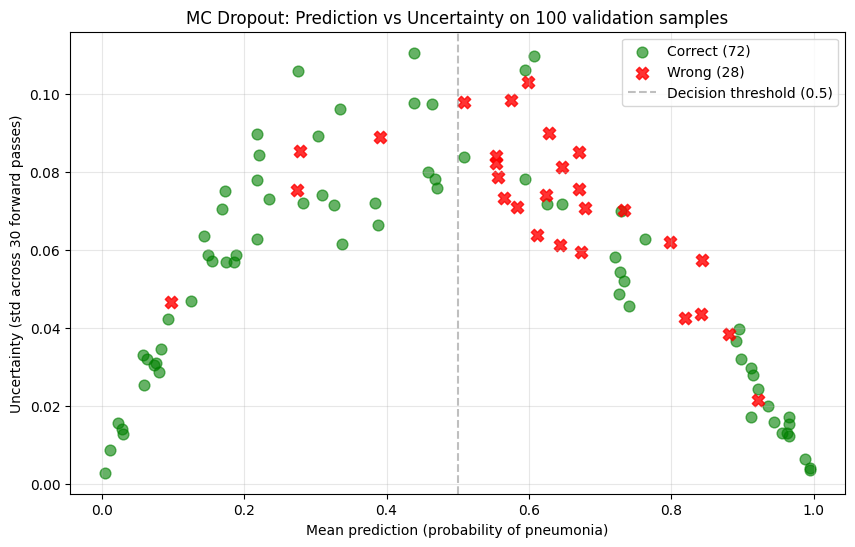

In [20]:
correct_df = results_df[results_df["correct"] == True]
wrong_df   = results_df[results_df["correct"] == False]

plt.figure(figsize=(10, 6))

plt.scatter(correct_df["mean_pred"], correct_df["std_pred"], 
            c="green", alpha=0.6, s=60, label=f"Correct ({len(correct_df)})")

plt.scatter(wrong_df["mean_pred"], wrong_df["std_pred"], 
            c="red", alpha=0.8, s=80, label=f"Wrong ({len(wrong_df)})", marker="X")

plt.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Decision threshold (0.5)")

plt.xlabel("Mean prediction (probability of pneumonia)")
plt.ylabel("Uncertainty (std across 30 forward passes)")
plt.title("MC Dropout: Prediction vs Uncertainty on 100 validation samples")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Threshold Analysis - Clinical Development 
### The table shown below evaluates uncertainty thresholds for a radiologic evaluation protocol.For each threshold, any prediction with a standard deviation larger than the threshold value is flagged for manual review by a radiologist.
### - A lower threshold (e.g. 0.04) is stricter - it flags more cases, catches more errors but keeps the manual workload high
### - A higher threshold(e.g. 0.10) is more lenient- it flags fewer cases but allows more errors to pass undetected

In [21]:
thresholds = [0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]

print(f"{'Threshold':<12} {'% Flagged':<12} {'% of Errors Caught':<20} {'Accuracy on Confident Cases'}")
print("-" * 75)

for t in thresholds:
    flagged = results_df[results_df["std_pred"] > t]
    confident = results_df[results_df["std_pred"] <= t]
    
    pct_flagged = len(flagged) / len(results_df) * 100
    errors_total = len(results_df[results_df["correct"] == False])
    errors_caught = len(flagged[flagged["correct"] == False])
    pct_errors_caught = errors_caught / errors_total * 100 if errors_total > 0 else 0
    
    if len(confident) > 0:
        acc_confident = confident["correct"].sum() / len(confident) * 100
    else:
        acc_confident = 0
    
    print(f"{t:<12.2f} {pct_flagged:<12.1f} {pct_errors_caught:<20.1f} {acc_confident:.1f}%")

Threshold    % Flagged    % of Errors Caught   Accuracy on Confident Cases
---------------------------------------------------------------------------
0.04         69.0         92.9                 93.5%
0.05         62.0         82.1                 86.8%
0.06         52.0         75.0                 85.4%
0.07         44.0         64.3                 82.1%
0.08         22.0         35.7                 76.9%
0.09         11.0         14.3                 73.0%
0.10         5.0          3.6                  71.6%


In [35]:
feature_maps = []
gradients = []

def forward_hook(module, input, output):
    """
    Capture feature maps during forward pass.

    Registered on the last convolutional layer to store
    the spatial feature representations for Grad-CAM.
    """
    feature_maps.append(output.clone())

def backward_hook(module, grad_input, grad_output):
    """
    Capture gradients during backward pass.

    Store gradients during backward flow through
    the last convolutional layer, used to compute
    importance weights for feature maps.
    """
    gradients.append(grad_output[0].clone())
#Clear all hooks first
for module in model.modules():
    module._forward_hooks.clear()
    module._backward_hooks.clear()
    
target_layer = model.features.denseblock4
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

In [39]:
def grad_cam(model, image):
    """
    Generates  a grad-CAM heatmap for a single image

    Computes gradient-weighted activation maps by catching feature_maps and gradients from the
    last convolutional layer through the usage of hooks.Gradients are averaged to produce importance weights per 
    feature_map, then combined into a single heatmap highlighting regions that most  influenced the prediction.

    Args:
        model: The trained model with hooks on target layer.
        image: Preprocessed tensor of shape [1, 3, 224, 224]
    
    Returns:
        heatmap:Numpy array with a shape(224, 224) with values normalized to 0-1.
        
    """
    feature_maps.clear()
    gradients.clear()

    #Step 1: Forward Pass
    output = model(image.to(DEVICE)).squeeze(1)

    #Step 2: Backward Pass
    model.zero_grad()
    output.backward()

    #Step 3: Get feature maps and gradients.
    fmaps = feature_maps[0]
    grads = gradients[0]

    #Step 4: Average gradients to get weights
    weights = grads.mean(dim = [2, 3])
    weights = weights.unsqueeze(-1).unsqueeze(-1)

    #Step 5: Weighted combination
    heatmap = (weights * fmaps).sum(dim = 1)

    heatmap = torch.relu(heatmap)

    # Step 7: Normalize to 0-1
    heatmap = heatmap.squeeze().cpu().detach().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
    
    # Step 8: Resize to match image
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((224, 224))
    heatmap = np.array(heatmap) / 255.0
    
    return heatmap
    
    



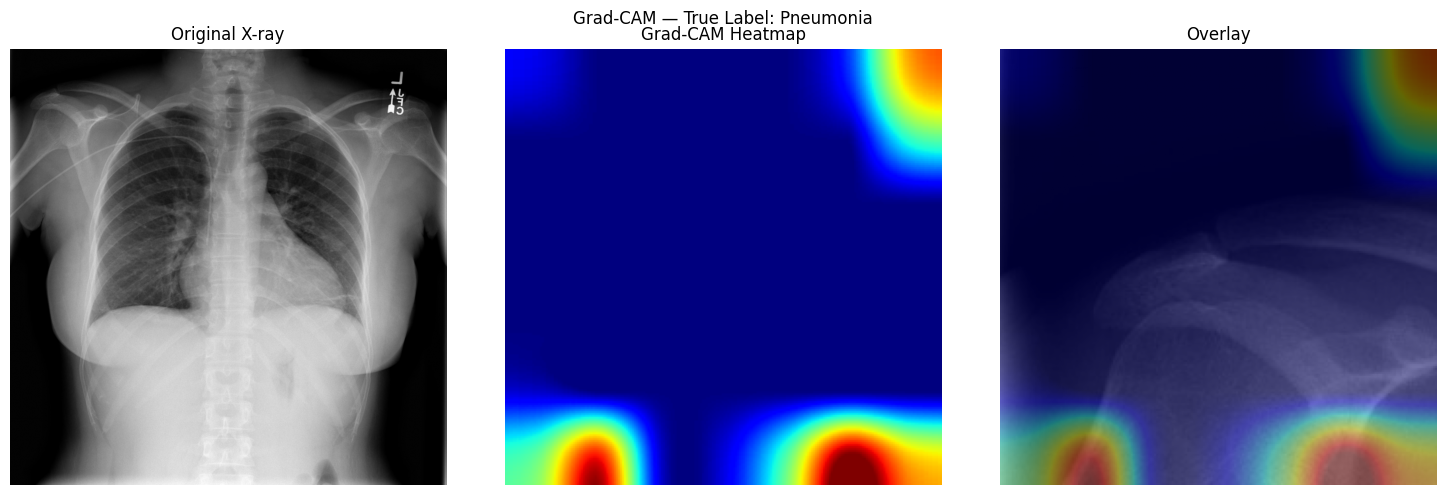

In [40]:
# Get a pneumonia case from validation set
for i in range(len(val_dataset)):
    img, label = val_dataset[i]
    if int(label) == 1:
        test_image = img.unsqueeze(0)
        test_label = int(label)
        test_index = i
        break

# Generate heatmap
heatmap = grad_cam(model, test_image)

# Load original image for overlay
row = val_df.iloc[test_index]
dicom = pydicom.dcmread(IMG_DIR + "/" + row["patientId"] + ".dcm")
original = dicom.pixel_array
original = (original - original.min()) / (original.max() - original.min())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original X-ray")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(original, cmap="gray")
axes[2].imshow(heatmap, cmap="jet", alpha=0.4)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.suptitle(f"Grad-CAM — True Label: {'Pneumonia' if test_label == 1 else 'Normal'}")
plt.tight_layout()
plt.show()


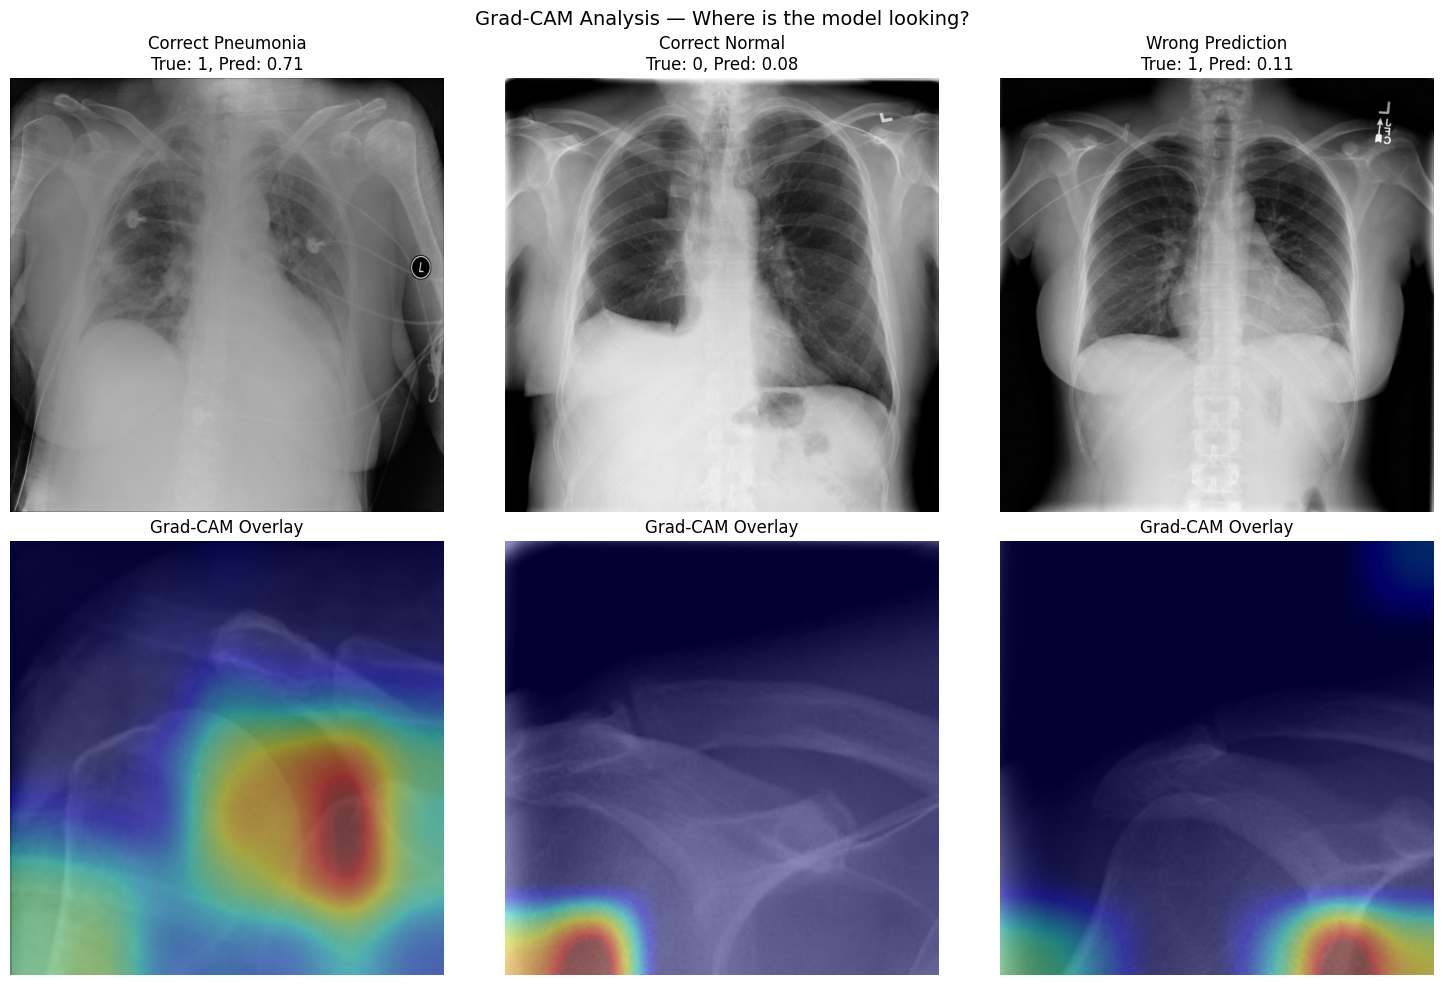

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cases = [
    ("Correct Pneumonia", 1, True),
    ("Correct Normal", 0, True),
    ("Wrong Prediction", None, False),
]

for col, (title, target_label, want_correct) in enumerate(cases):
    # Find a matching case
    for i in range(len(val_dataset)):
        img, label = val_dataset[i]
        test_img = img.unsqueeze(0)
        
        with torch.no_grad():
            pred = torch.sigmoid(model(test_img.to(DEVICE)).squeeze(1)).item()
        predicted = 1 if pred > 0.5 else 0
        correct = predicted == int(label)
        
        if want_correct and correct and int(label) == target_label:
            break
        elif not want_correct and not correct:
            break
    
    # Generate heatmap
    heatmap = grad_cam(model, test_img)
    
    # Load original
    row = val_df.iloc[i]
    dicom = pydicom.dcmread(IMG_DIR + "/" + row["patientId"] + ".dcm")
    original = dicom.pixel_array
    original = (original - original.min()) / (original.max() - original.min())
    
    # Top row: original
    axes[0, col].imshow(original, cmap="gray")
    axes[0, col].set_title(f"{title}\nTrue: {int(label)}, Pred: {pred:.2f}")
    axes[0, col].axis("off")
    
    # Bottom row: overlay
    axes[1, col].imshow(original, cmap="gray")
    axes[1, col].imshow(heatmap, cmap="jet", alpha=0.4)
    axes[1, col].set_title("Grad-CAM Overlay")
    axes[1, col].axis("off")

plt.suptitle("Grad-CAM Analysis — Where is the model looking?", fontsize=14)
plt.tight_layout()
plt.show()